# AGEB rurales desde el ITER nacional (localidades) y el marco 2020

Hitos **R0–R3** de `docs/planes/05-ageb-rural.md`. El ITER nacional publica una fila
por **localidad** (urbana y rural) con las 230 variables del cuestionario
básico. Las localidades rurales son puntos en el marco (`00lpr`) y cada
punto trae la clave de su **AGEB rural**; sumando las localidades de cada
AGEB se obtienen, para las 17 469 AGEB rurales, los mismos indicadores que
ya tienen las urbanas (mismo denominador `VIVPARH_CV`, misma censura).

Hechos del ITER nacional que condicionan el diseño:

- **Localidades de 1 o 2 viviendas** (82 012, 408 mil personas): INEGI sólo
  publica su población y total de viviendas; todos los indicadores vienen
  con `*`. Su detalle aparece agregado por municipio en filas especiales
  (`LOC` 9998 "localidades de una vivienda" y 9999 "de dos viviendas"), que
  no se pueden asignar a AGEB. Aquí cuentan en la **población** de la AGEB
  pero no en el denominador de los indicadores; se reporta cuántas son.
- Algunas localidades traen `N/D` (visitadas sin poder recopilar datos).
- La suma de las filas de localidad (sin 9998/9999) es la población nacional.

Salida: filas rurales **añadidas** a `medi_ageb_2020.parquet` (`ambito =
rural`, clave de 9) y la tabla puente `medi_ageb_2020_grid.parquet`
ampliada con **una fila por localidad rural** (su punto → celda UTCI), de
modo que el resumen por celda y la regla climática incluyan lo rural.
Orden del pipeline: 005 → 006 → **011** → 008 → 009 → 010 → 007.

In [1]:
import hashlib
import io
import urllib.request
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
RAW_INEGI = ROOT / "data" / "raw" / "INEGI"
ITER_NAC = RAW_INEGI / "iter_2020" / "iter_nacional"
MGN_ZIP = RAW_INEGI / "mg_2020" / "mg_2020_integrado.zip"
MGN_DIR = RAW_INEGI / "mg_2020" / "conjunto_de_datos"
OUT = ROOT / "data" / "derived" / "INEGI" / "2020"
AGEB_PARQUET = OUT / "medi_ageb_2020.parquet"
GRID_PARQUET = OUT / "medi_ageb_2020_grid.parquet"
URL = "https://www.inegi.org.mx/contenidos/programas/ccpv/2020/datosabiertos/iter/iter_00_cpv2020_csv.zip"
POB_NACIONAL_2020 = 126_014_024
EPSG_MGN, EPSG_OUT, GRID_RES = 6372, 4326, 0.25
ITER_NAC.mkdir(parents=True, exist_ok=True)
assert AGEB_PARQUET.exists() and GRID_PARQUET.exists(), "corre primero 005 y 006"

NUM = ["POBTOT", "VIVPAR_HAB", "VIVPARH_CV", "VPH_C_ELEC", "VPH_S_ELEC", "VPH_REFRI", "VPH_SINRTV", "VPH_SINLTC"]
INDS = {  # id -> (numerador, bandera, complemento?)
    "elec": ("VPH_S_ELEC", "flag_elec"), "refri": ("VPH_REFRI", "flag_refri"),
    "telef": ("VPH_SINLTC", "flag_telef"), "rtv": ("VPH_SINRTV", "flag_rtv"),
}

## R0. Descarga del ITER nacional y lectura de localidades

In [2]:
def remote_size(url):
    with urllib.request.urlopen(urllib.request.Request(url, method="HEAD"), timeout=60) as r:
        return int(r.headers["Content-Length"])


zip_path = ITER_NAC / "iter_00_cpv2020_csv.zip"
size = remote_size(URL)
if not (zip_path.exists() and zip_path.stat().st_size == size):
    with urllib.request.urlopen(URL, timeout=600) as r, open(zip_path, "wb") as f:
        while b := r.read(1 << 20):
            f.write(b)
sha = hashlib.sha256(zip_path.read_bytes()).hexdigest()
with zipfile.ZipFile(zip_path) as z:
    name = [n for n in z.namelist() if n.lower().endswith(".csv") and "conjunto_de_datos_iter" in n.lower()][0]
    raw = z.read(name)
try:
    text = raw.decode("utf-8-sig")
except UnicodeDecodeError:
    text = raw.decode("latin-1")
it = pd.read_csv(io.StringIO(text), dtype=str, usecols=["ENTIDAD", "NOM_ENT", "MUN", "NOM_MUN", "LOC", "NOM_LOC"] + NUM)
print(f"{zip_path.name}: {size/1e6:.1f} MB, sha256 {sha[:12]}…, {len(it):,} filas")

nacional = int(it.loc[(it["ENTIDAD"] == "00") & (it["MUN"] == "000") & (it["LOC"] == "0000"), "POBTOT"].iloc[0])
assert nacional == POB_NACIONAL_2020, nacional
loc = it[(it["ENTIDAD"] != "00") & (it["MUN"] != "000") & ~it["LOC"].isin(["0000", "9998", "9999"])].copy()
loc["cve_ent"], loc["cve_mun"], loc["cve_loc"] = loc["ENTIDAD"].str.zfill(2), loc["MUN"].str.zfill(3), loc["LOC"].str.zfill(4)
loc["cve_locg"] = loc["cve_ent"] + loc["cve_mun"] + loc["cve_loc"]
for c in NUM:
    loc[c] = pd.to_numeric(loc[c].replace({"*": pd.NA, "N/D": pd.NA}), errors="coerce").astype("Int64")
assert int(loc["POBTOT"].sum()) == POB_NACIONAL_2020, int(loc["POBTOT"].sum())
print(f"localidades: {len(loc):,}; población = nacional ✓; sin VIVPARH_CV (1–2 viviendas o N/D): {int(loc['VIVPARH_CV'].isna().sum()):,} "
      f"con {int(loc.loc[loc['VIVPARH_CV'].isna(), 'POBTOT'].sum()):,} personas")

(ITER_NAC / "SOURCE.md").write_text(f"""# ITER 2020 nacional (INEGI) — procedencia

- **Producto:** Principales resultados por localidad (ITER), Censo de Población y Vivienda 2020, archivo nacional.
- **Descarga:** {URL}
- **Fecha de descarga:** {datetime.now(timezone.utc):%Y-%m-%d}
- **Tamaño:** {size} bytes · **SHA-256:** `{sha}`
- **Uso:** filas de localidad (urbanas y rurales) para construir las AGEB rurales (libreta 011).
- **Licencia:** Términos de Libre Uso de la Información del INEGI.
""", encoding="utf-8")

iter_00_cpv2020_csv.zip: 36.6 MB, sha256 9342fdbd45bd…, 195,662 filas


localidades: 189,432; población = nacional ✓; sin VIVPARH_CV (1–2 viviendas o N/D): 81,257 con 414,737 personas


585

## R1. Localidad rural → AGEB rural (puntos `00lpr` del marco)

In [3]:
lpr = gpd.read_file(f"zip://{MGN_ZIP}!conjunto_de_datos/00lpr.shp").set_crs(EPSG_MGN, allow_override=True)
lpr["cve_locg"] = lpr["CVE_ENT"] + lpr["CVE_MUN"] + lpr["CVE_LOC"]
lpr["cve_ageb9"] = lpr["CVE_ENT"] + lpr["CVE_MUN"] + lpr["CVE_AGEB"]
lpr = lpr.drop_duplicates("cve_locg")
print(f"puntos rurales: {len(lpr):,} en {lpr['cve_ageb9'].nunique():,} AGEB rurales")

urb_locs = set(pd.read_parquet(AGEB_PARQUET, columns=["cve_ent", "cve_mun", "cve_loc"]).agg("".join, axis=1))
rur = loc.merge(lpr[["cve_locg", "cve_ageb9", "geometry"]], on="cve_locg", how="inner")
rur = rur[~rur["cve_locg"].isin(urb_locs)]          # nunca contar una localidad urbana ya cubierta por su AGEB urbana
sin_punto = loc[~loc["cve_locg"].isin(lpr["cve_locg"]) & ~loc["cve_locg"].isin(urb_locs)]
print(f"localidades rurales con punto y AGEB: {len(rur):,} ({int(rur['POBTOT'].sum()):,} personas)")
print(f"localidades del ITER sin punto rural ni AGEB urbana: {len(sin_punto):,} ({int(sin_punto['POBTOT'].sum()):,} personas) — "
      "son localidades urbanas sin fila AGEB (p. ej. las 331 mixtas) u omisiones del marco")
assert rur["POBTOT"].sum() > 20_000_000, "muy poca población rural asignada"

puntos rurales: 295,779 en 16,399 AGEB rurales


localidades rurales con punto y AGEB: 184,190 (25,673,525 personas)
localidades del ITER sin punto rural ni AGEB urbana: 0 (0 personas) — son localidades urbanas sin fila AGEB (p. ej. las 331 mixtas) u omisiones del marco


## R2. Sumas por AGEB rural, banderas e indicadores
Numerador y denominador se suman sobre las localidades **con dato**; las de
1–2 viviendas aportan población y se cuentan en `n_loc_sin_dato`. Cota
superior por censura de numerador: 2 viviendas por localidad censurada.

In [4]:
rur = gpd.GeoDataFrame(rur, geometry="geometry", crs=EPSG_MGN)
g = rur.groupby("cve_ageb9")
agg = pd.DataFrame({
    "pobtot": g["POBTOT"].sum().astype("int64"),
    "n_localidades": g.size(),
    "n_loc_sin_dato": g["VIVPARH_CV"].apply(lambda s: int(s.isna().sum())),
    "vivpar_hab": g["VIVPAR_HAB"].sum(min_count=1),
    "vivparh_cv": g["VIVPARH_CV"].sum(min_count=1),
    "nom_ent": g["NOM_ENT"].first(), "nom_mun": g["NOM_MUN"].first(),
})
den_all = rur.set_index("cve_ageb9")["VIVPARH_CV"]
for k, (num, flag) in INDS.items():
    d = rur[["cve_ageb9", "VIVPARH_CV", num]].copy()
    ok = d["VIVPARH_CV"].notna() & d[num].notna()
    cens = d["VIVPARH_CV"].notna() & d[num].isna()
    s_num = d[ok].groupby("cve_ageb9")[num].sum()
    s_den = d[ok].groupby("cve_ageb9")["VIVPARH_CV"].sum()
    n_cens = d[cens].groupby("cve_ageb9").size()
    den_cens = d[cens].groupby("cve_ageb9")["VIVPARH_CV"].sum()
    agg[f"num_{k}"] = s_num.reindex(agg.index)
    agg[f"den_{k}"] = s_den.reindex(agg.index)
    agg[f"n_loc_cens_{k}"] = n_cens.reindex(agg.index).fillna(0).astype("int64")
    agg[f"den_cens_{k}"] = den_cens.reindex(agg.index).fillna(0)
agg["vph_c_elec"] = rur[rur["VPH_C_ELEC"].notna()].groupby("cve_ageb9")["VPH_C_ELEC"].sum().reindex(agg.index)

def pct(num, den):
    return (num.astype("float64") / den.astype("float64") * 100).where(den > 0)

out = agg[["nom_ent", "nom_mun", "pobtot", "n_localidades", "n_loc_sin_dato", "vivpar_hab", "vivparh_cv", "vph_c_elec"]].copy()
out["vph_s_elec"] = agg["num_elec"]; out["vph_refri"] = agg["num_refri"]
out["vph_sinltc"] = agg["num_telef"]; out["vph_sinrtv"] = agg["num_rtv"]
out["vph_sin_refri"] = (agg["den_refri"] - agg["num_refri"])
out["p_sin_elec"] = pct(agg["num_elec"], agg["den_elec"])
out["p_sin_refri"] = pct(agg["den_refri"] - agg["num_refri"], agg["den_refri"])
out["p_sin_telef"] = pct(agg["num_telef"], agg["den_telef"])
out["p_sin_rtv"] = pct(agg["num_rtv"], agg["den_rtv"])
# cota superior de electricidad: numerador conocido + 2 por localidad censurada, sobre todo el denominador conocido
out["p_sin_elec_sup"] = ((agg["num_elec"].fillna(0) + 2 * agg["n_loc_cens_elec"]) /
                         (agg["den_elec"].fillna(0) + agg["den_cens_elec"]) * 100).where((agg["den_elec"].fillna(0) + agg["den_cens_elec"]) > 0).clip(upper=100)
for k, (num, flag) in INDS.items():
    out[flag] = np.select([agg[f"den_{k}"].fillna(0) > 0, agg["vivparh_cv"].fillna(0) > 0], ["ok", "censurado"], "sin_viviendas")
    out[f"cobertura_{k}"] = (agg[f"den_{k}"].fillna(0) / (agg[f"den_{k}"].fillna(0) + agg[f"den_cens_{k}"])).where((agg[f"den_{k}"].fillna(0) + agg[f"den_cens_{k}"]) > 0)
for c in ["p_sin_elec", "p_sin_refri", "p_sin_telef", "p_sin_rtv"]:
    s = out[c].dropna(); assert ((s >= 0) & (s <= 100)).all(), c
print("AGEB rurales con datos:", len(out), "| flags elec:", out["flag_elec"].value_counts().to_dict(), "| refri:", out["flag_refri"].value_counts().to_dict())
print("cobertura media del denominador con dato (elec):", round(float(out["cobertura_elec"].mean()), 3))
print(out[["p_sin_elec", "p_sin_refri", "p_sin_telef", "p_sin_rtv"]].describe().round(1).T)

AGEB rurales con datos: 14868 | flags elec: {'ok': 12873, 'sin_viviendas': 1995} | refri: {'ok': 12873, 'sin_viviendas': 1995}
cobertura media del denominador con dato (elec): 1.0
               count  mean   std  min   25%   50%   75%    max
p_sin_elec   12873.0   6.0  15.1  0.0   0.4   1.4   3.8  100.0
p_sin_refri  12873.0  27.8  26.1  0.0   8.4  18.6  39.3  100.0
p_sin_telef  12873.0  27.7  21.7  0.0  11.6  21.2  38.5  100.0
p_sin_rtv    12873.0  15.5  16.9  0.0   4.7   9.9  19.9  100.0


## R2 (cont.). Geometría rural, centroides y escritura junto a las urbanas

In [5]:
a = gpd.read_file(MGN_DIR / "00a.shp").set_crs(EPSG_MGN, allow_override=True)
rur_poly = a[a["Ambito"] == "Rural"][["CVEGEO", "CVE_ENT", "CVE_MUN", "CVE_AGEB", "geometry"]]
gr = out.merge(rur_poly, left_index=True, right_on="CVEGEO", how="inner")
print(f"AGEB rurales con polígono: {len(gr):,} de {len(out):,}; polígonos rurales sin localidad con datos: {len(rur_poly) - len(gr):,}")
gr = gpd.GeoDataFrame(gr, geometry="geometry", crs=EPSG_MGN)
cent = gr.geometry.centroid.to_crs(EPSG_OUT)
gr["cent_lon"], gr["cent_lat"] = cent.x, cent.y
gr = gr.to_crs(EPSG_OUT)
gr["cvegeo"] = gr["CVEGEO"]; gr["cve_ent"] = gr["CVE_ENT"]; gr["cve_mun"] = gr["CVE_MUN"]; gr["cve_ageb"] = gr["CVE_AGEB"]
gr["cve_loc"] = None; gr["nom_loc"] = None; gr["ambito"] = "rural"; gr["ambito_mgn"] = "rural"

urb = gpd.read_parquet(AGEB_PARQUET)
if "ambito" in urb.columns:
    urb = urb[urb["ambito"] != "rural"]      # idempotente: quita rurales de una corrida anterior
urb["ambito"] = "urbana"
cols = list(urb.columns)
for c in ["n_localidades", "n_loc_sin_dato", "cobertura_elec", "cobertura_refri", "cobertura_telef", "cobertura_rtv"]:
    if c not in cols:
        cols.append(c)
gr = gr.reindex(columns=cols)
todo = pd.concat([urb.reindex(columns=cols), gr], ignore_index=True)
todo = gpd.GeoDataFrame(todo, geometry="geometry", crs=EPSG_OUT).sort_values("cvegeo").reset_index(drop=True)
for c in ["pobtot", "vivpar_hab", "vivparh_cv", "vph_c_elec", "vph_s_elec", "vph_refri", "vph_sin_refri", "vph_sinrtv", "vph_sinltc", "n_localidades", "n_loc_sin_dato"]:
    todo[c] = pd.to_numeric(todo[c]).astype("Int64")
assert todo["cvegeo"].is_unique
todo.to_parquet(AGEB_PARQUET, index=False, write_covering_bbox=True)
print("escrito", AGEB_PARQUET.name, todo.shape, "| urbanas:", int((todo["ambito"] == "urbana").sum()), "| rurales:", int((todo["ambito"] == "rural").sum()),
      f"| {AGEB_PARQUET.stat().st_size/1e6:.1f} MB")

AGEB rurales con polígono: 14,868 de 14,868; polígonos rurales sin localidad con datos: 2,601


escrito medi_ageb_2020.parquet (79181, 59) | urbanas: 64313 | rurales: 14868 | 202.8 MB


## R3. Tabla puente: una fila por localidad rural (punto → celda UTCI)
Se conservan las filas urbanas (una por AGEB) y se añaden las rurales con
`unidad = localidad`, los conteos de la localidad y su AGEB rural en `cvegeo`.

In [6]:
def to_cell(x):
    return (np.round(x / GRID_RES) * GRID_RES).round(2)

pts = rur.to_crs(EPSG_OUT)
locg = pd.DataFrame({
    "cvegeo": pts["cve_ageb9"], "unidad": "localidad", "cve_loc": pts["cve_locg"], "nom_loc": pts["NOM_LOC"],
    "lat_c": to_cell(pts.geometry.y), "lon_c": to_cell(pts.geometry.x),
    "pobtot": pts["POBTOT"], "vivparh_cv": pts["VIVPARH_CV"],
    "vph_s_elec": pts["VPH_S_ELEC"], "vph_c_elec": pts["VPH_C_ELEC"], "vph_refri": pts["VPH_REFRI"],
    "vph_sin_refri": (pts["VIVPARH_CV"] - pts["VPH_REFRI"]), "vph_sinltc": pts["VPH_SINLTC"], "vph_sinrtv": pts["VPH_SINRTV"],
})
for k, (num, flag) in INDS.items():
    den_ok = pts["VIVPARH_CV"].notna() & (pts["VIVPARH_CV"] > 0)
    locg[flag] = np.select([den_ok & pts[num].notna(), den_ok], ["ok", "censurado"], "sin_viviendas")
grid = pd.read_parquet(GRID_PARQUET)
if "unidad" in grid.columns:
    grid = grid[grid["unidad"] != "localidad"]   # idempotente
grid["unidad"] = "ageb"
grid = pd.concat([grid, locg.reindex(columns=list(dict.fromkeys(list(grid.columns) + list(locg.columns))))], ignore_index=True)
grid.to_parquet(GRID_PARQUET, index=False)
print("tabla puente:", grid.shape, "| filas AGEB urbana:", int((grid['unidad'] == 'ageb').sum()), "| localidades rurales:", int((grid['unidad'] == 'localidad').sum()))
celdas = grid.groupby(["lat_c", "lon_c"]).size()
print("celdas con alguna unidad:", len(celdas), "(antes sólo urbanas: 1 381)")

tabla puente: (248503, 27) | filas AGEB urbana: 64313 | localidades rurales: 184190


celdas con alguna unidad: 2929 (antes sólo urbanas: 1 381)


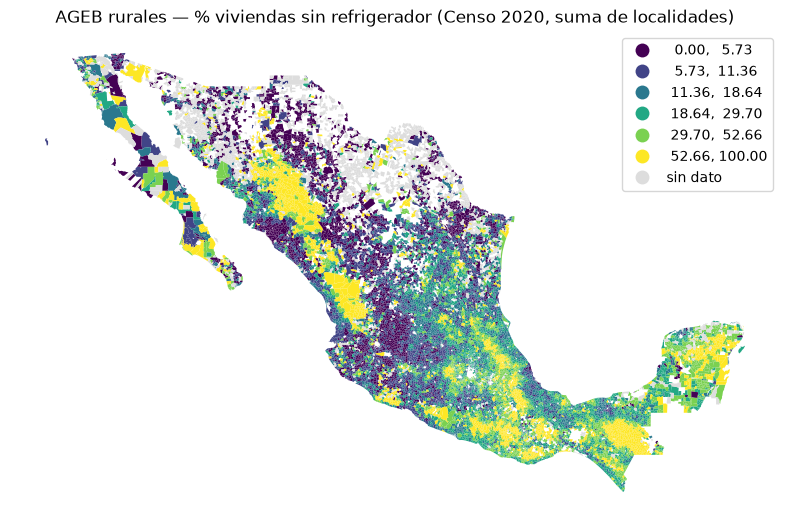

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
todo[todo["ambito"] == "rural"].plot(column="p_sin_refri", ax=ax, cmap="viridis", legend=True, scheme="quantiles", k=6, edgecolor="none",
                                    missing_kwds={"color": "#dddddd", "label": "sin dato"})
ax.set_title("AGEB rurales — % viviendas sin refrigerador (Censo 2020, suma de localidades)")
ax.set_axis_off()
plt.tight_layout()